In [1]:
import numpy as np
import pandas as pd

In [2]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (16, 9)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [4]:
medical_data = pd.read_csv('medical-charges.csv')
medical_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
medical_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
medical_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
medical_data.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

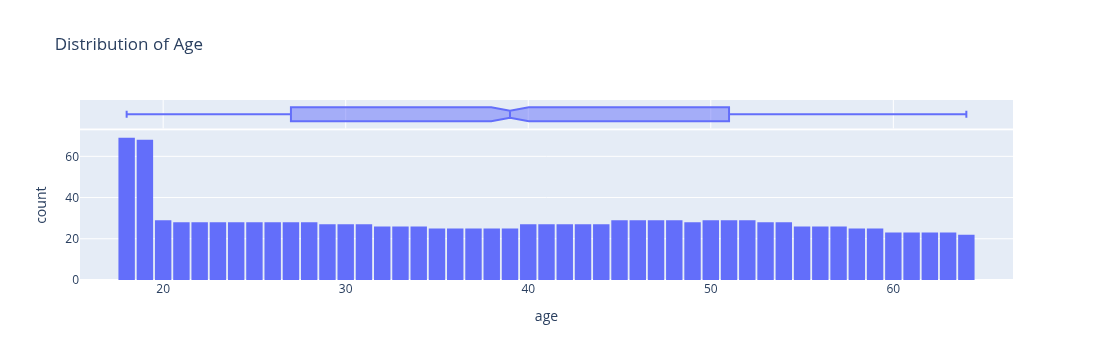

In [8]:
fig = px.histogram(medical_data, 
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

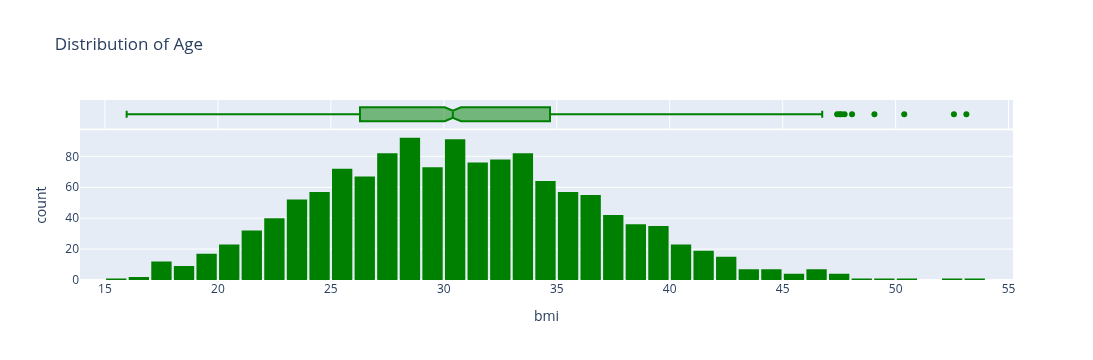

In [9]:
fig = px.histogram(medical_data, 
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['green'],
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

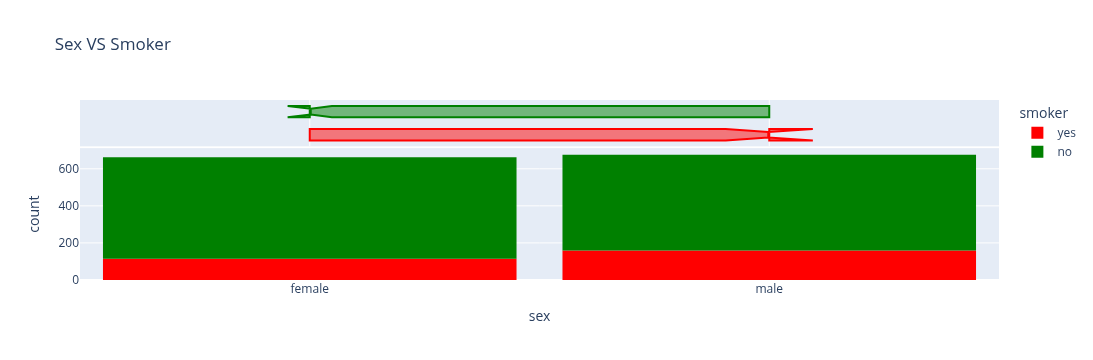

In [10]:
fig = px.histogram(medical_data, 
                   x='sex',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['red', 'green'],
                   title='Sex VS Smoker')
fig.update_layout(bargap=0.1)
fig.show()

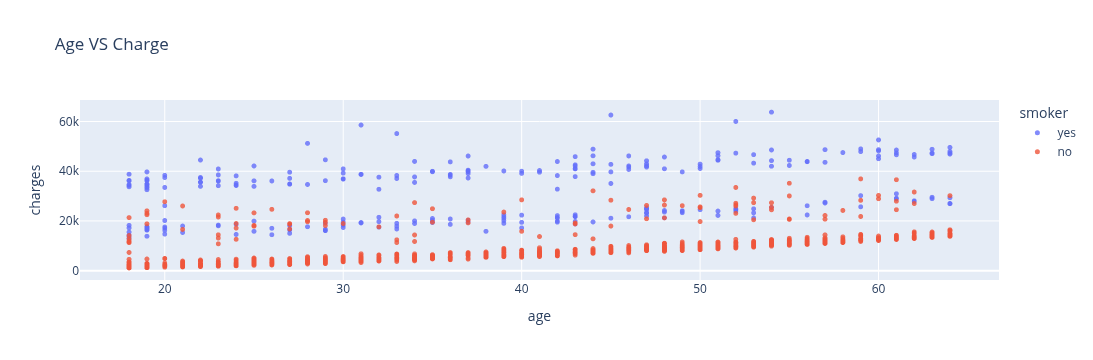

In [11]:
fig = px.scatter(medical_data, 
                   x='age',
                   y='charges',
                   color='smoker',
                   opacity=0.8,
                   hover_data=['sex'],
                   title='Age VS Charge')
fig.update_traces(marker_size=5)
fig.show()

In [12]:
smoker_values={'no' : 0, 'yes' : 1}
sex_values={'male':0, 'female':1}

In [13]:
medical_data['smoker'] = medical_data['smoker'].map(smoker_values)
medical_data['sex'] = medical_data['sex'].map(sex_values)
medical_data

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [14]:
medical_data.age.corr(medical_data.charges)

np.float64(0.29900819333064754)

In [15]:
medical_data.age.corr(medical_data.children)

np.float64(0.04246899855884944)

In [16]:
medical_data.age.corr(medical_data.smoker)

np.float64(-0.025018751536285088)

# Linear Regression

In [17]:
X = medical_data[['age']]
X

,age
0,19
1,18
2,28
3,33
4,32
...,...
1333,50
1334,18
1335,18
1336,21


In [18]:
X_mean = np.mean(X['age'].values)
X_std = np.std(X['age'].values)
X_scaled = (X - X_mean) / X_std
X_scaled

,age
0,-1.438764
1,-1.509965
2,-0.797954
3,-0.441948
4,-0.513149
...,...
1333,0.768473
1334,-1.509965
1335,-1.509965
1336,-1.296362


In [19]:
y = medical_data['charges']
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
linear_model = LinearRegression()

In [22]:
linear_model.fit(X_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
from sklearn.linear_model import SGDRegressor

In [24]:
SGD_model = SGDRegressor()

In [25]:
SGD_model.fit(X_scaled, y)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [26]:
linear_prediction = linear_model.predict(X_scaled)

In [27]:
SGD_Prediction = SGD_model.predict(X_scaled)

In [28]:
# def rmse(targets, predictions):
#     return np.sqrt(np.mean(np.square(targets - predictions)))

def rmse(targets, predictions):
    # np.asarray() safely handles both Pandas Series/DataFrames and NumPy arrays
    t_vals = np.asarray(targets).flatten()
    p_vals = np.asarray(predictions).flatten()

    return np.sqrt(np.mean(np.square(t_vals - p_vals)))

In [29]:
rmse(y, linear_prediction)

np.float64(11551.66562075632)

In [30]:
rmse(y, SGD_Prediction)

np.float64(11551.697802698287)

In [31]:
def estimate_charges(age, w, b):
    return w * age + b

In [32]:
def try_parameters(w, b):
    ages = X_scaled
    target = y
    predictions = estimate_charges(ages, w, b)
    
    plt.plot(X, predictions, 'r', alpha=0.9);
    plt.scatter(X, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);
    
    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

# def try_parameters(w, b):
#     ages = X_scaled
#     target = y
#     predictions = estimate_charges(ages, w, b)
    
#     # FIX: Use plt.scatter instead of plt.plot so it doesn't zig-zag!
#     plt.scatter(X, predictions, color='red', s=8, alpha=0.9)
#     plt.scatter(X, target, s=8, alpha=0.8)
#     plt.xlabel('Age')
#     plt.ylabel('Charges')
#     plt.legend(['Prediction', 'Actual'])
    
#     loss = rmse(target, predictions)
#     print("RMSE Loss: ", loss)

RMSE Loss:  11551.66562075632


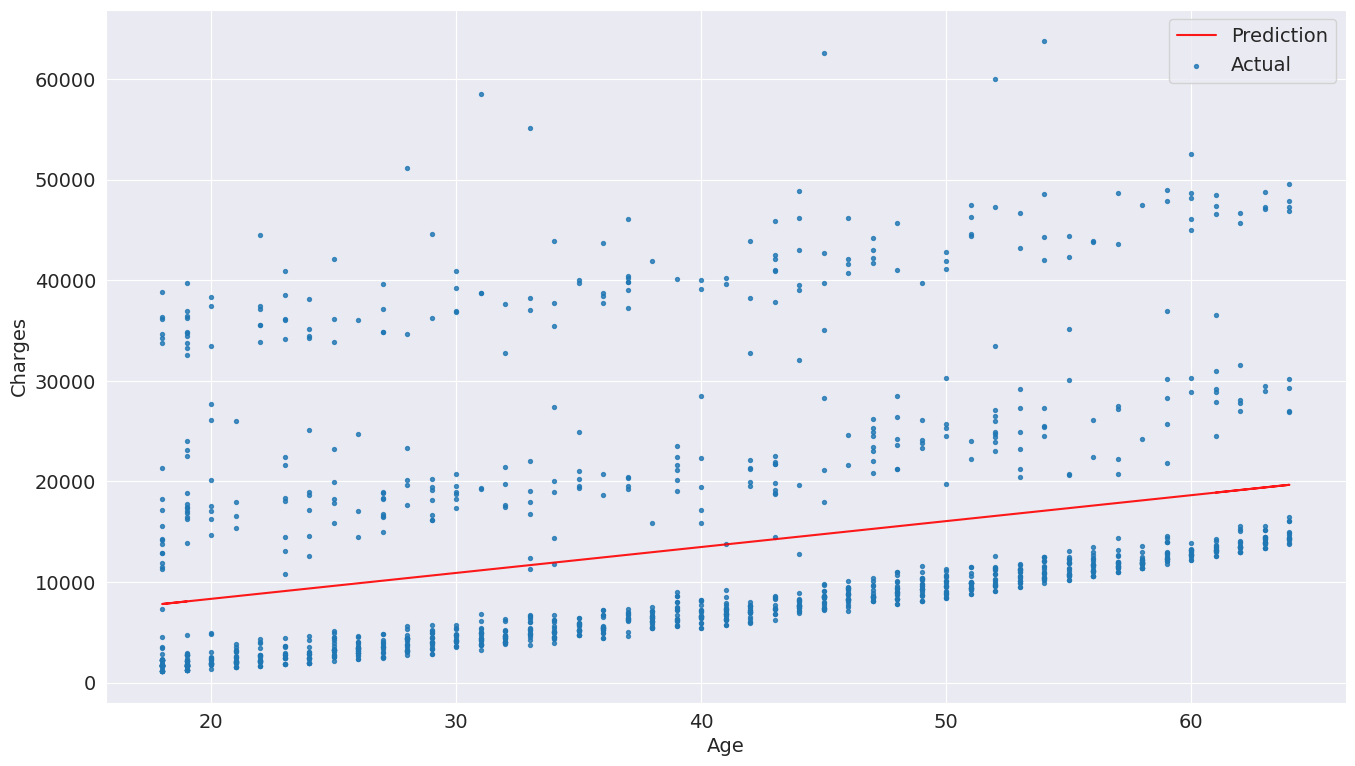

In [33]:
try_parameters(linear_model.coef_, linear_model.intercept_)

RMSE Loss:  11551.697802698287


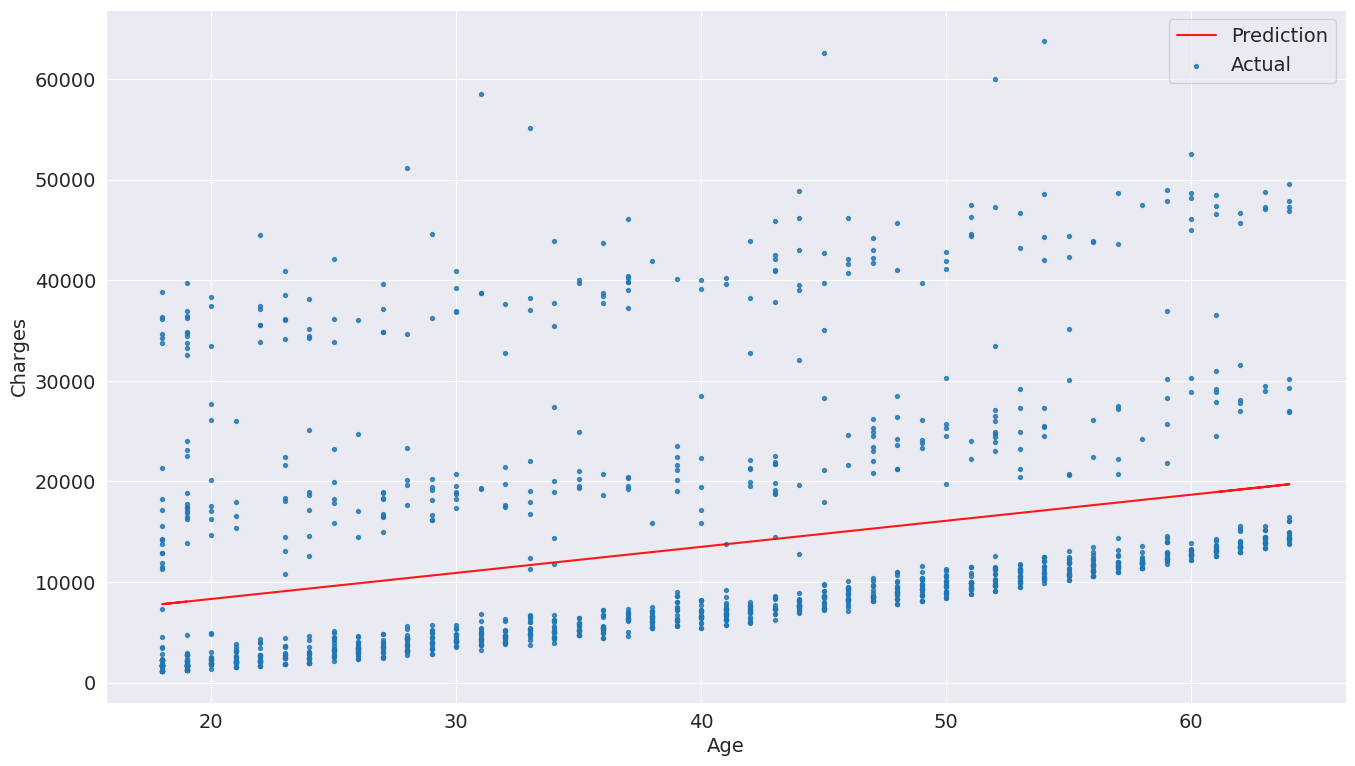

In [34]:
try_parameters(SGD_model.coef_, SGD_model.intercept_)

# Multiple Features

In [35]:
input_data = medical_data[['age', 'bmi', 'children', 'smoker', 'sex']]
input_data

,age,bmi,children,smoker,sex
0,19,27.900,0,1,1
1,18,33.770,1,0,0
2,28,33.000,3,0,0
3,33,22.705,0,0,0
4,32,28.880,0,0,0
...,...,...,...,...,...
1333,50,30.970,3,0,0
1334,18,31.920,0,0,1
1335,18,36.850,0,0,1
1336,21,25.800,0,0,1


In [36]:
input_data_scaled = input_data.copy()
for column in input_data.columns:
    input_data_scaled[column] = (input_data[column] - np.mean(input_data[column])) / np.std(input_data[column])

input_data_scaled

,age,bmi,children,smoker,sex
0,-1.438764,-0.453320,-0.908614,1.970587,1.010519
1,-1.509965,0.509621,-0.078767,-0.507463,-0.989591
2,-0.797954,0.383307,1.580926,-0.507463,-0.989591
3,-0.441948,-1.305531,-0.908614,-0.507463,-0.989591
4,-0.513149,-0.292556,-0.908614,-0.507463,-0.989591
...,...,...,...,...,...
1333,0.768473,0.050297,1.580926,-0.507463,-0.989591
1334,-1.509965,0.206139,-0.908614,-0.507463,1.010519
1335,-1.509965,1.014878,-0.908614,-0.507463,1.010519
1336,-1.296362,-0.797813,-0.908614,-0.507463,1.010519


In [37]:
input_data

,age,bmi,children,smoker,sex
0,19,27.900,0,1,1
1,18,33.770,1,0,0
2,28,33.000,3,0,0
3,33,22.705,0,0,0
4,32,28.880,0,0,0
...,...,...,...,...,...
1333,50,30.970,3,0,0
1334,18,31.920,0,0,1
1335,18,36.850,0,0,1
1336,21,25.800,0,0,1


In [38]:
target_data = medical_data['charges']
target_data

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [39]:
multivariate_model = LinearRegression()
multivariate_model.fit(input_data_scaled, target_data)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
multivariate_prediction = multivariate_model.predict(input_data_scaled)

In [41]:
rmse(target_data, multivariate_prediction)

np.float64(6056.100708754546)

# With categorical data (Region)

In [42]:
from sklearn import preprocessing

In [48]:
# 1. Initialize the encoder, dropping the first category to avoid multicollinearity
# (Setting sparse_output=False removes the need to call .toarray() later)
encoder = preprocessing.OneHotEncoder(drop='first', sparse_output=False)

In [49]:
# 2. Fit and transform the data in one step
one_hot_encoding = encoder.fit_transform(medical_data[['region']])

In [50]:
# 3. Get the correct column names (this will automatically exclude the dropped category)
regions = encoder.get_feature_names_out(['region'])

In [51]:
# 4. Assign the encoded data back to the dataframe
medical_data[regions] = one_hot_encoding

In [52]:
medical_data

,age,sex,bmi,children,smoker,region,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,southwest,16884.92400,0.0,0.0,1.0
1,18,0,33.770,1,0,southeast,1725.55230,0.0,1.0,0.0
2,28,0,33.000,3,0,southeast,4449.46200,0.0,1.0,0.0
3,33,0,22.705,0,0,northwest,21984.47061,1.0,0.0,0.0
4,32,0,28.880,0,0,northwest,3866.85520,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830,1.0,0.0,0.0
1334,18,1,31.920,0,0,northeast,2205.98080,0.0,0.0,0.0
1335,18,1,36.850,0,0,southeast,1629.83350,0.0,1.0,0.0
1336,21,1,25.800,0,0,southwest,2007.94500,0.0,0.0,1.0


In [53]:
medical_data = medical_data.drop(columns=['region'])
medical_data

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0.0,0.0,1.0
1,18,0,33.770,1,0,1725.55230,0.0,1.0,0.0
2,28,0,33.000,3,0,4449.46200,0.0,1.0,0.0
3,33,0,22.705,0,0,21984.47061,1.0,0.0,0.0
4,32,0,28.880,0,0,3866.85520,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1.0,0.0,0.0
1334,18,1,31.920,0,0,2205.98080,0.0,0.0,0.0
1335,18,1,36.850,0,0,1629.83350,0.0,1.0,0.0
1336,21,1,25.800,0,0,2007.94500,0.0,0.0,1.0


In [54]:
features = []
targetc = ''
for column in medical_data.columns:
    if column == 'charges':
        targetc = column
    else:
        features.append(column)

print(features)
print(targetc)

['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
charges


In [55]:
input_data = medical_data[features]
input_data

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0.0,0.0,1.0
1,18,0,33.770,1,0,0.0,1.0,0.0
2,28,0,33.000,3,0,0.0,1.0,0.0
3,33,0,22.705,0,0,1.0,0.0,0.0
4,32,0,28.880,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1.0,0.0,0.0
1334,18,1,31.920,0,0,0.0,0.0,0.0
1335,18,1,36.850,0,0,0.0,1.0,0.0
1336,21,1,25.800,0,0,0.0,0.0,1.0


In [56]:
input_data

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0.0,0.0,1.0
1,18,0,33.770,1,0,0.0,1.0,0.0
2,28,0,33.000,3,0,0.0,1.0,0.0
3,33,0,22.705,0,0,1.0,0.0,0.0
4,32,0,28.880,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1.0,0.0,0.0
1334,18,1,31.920,0,0,0.0,0.0,0.0
1335,18,1,36.850,0,0,0.0,1.0,0.0
1336,21,1,25.800,0,0,0.0,0.0,1.0


In [57]:
input_data_scaled = input_data.copy()
for column in input_data.columns:
    input_data_scaled[column] = (input_data[column] - np.mean(input_data[column])) / np.std(input_data[column])

input_data_scaled

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.438764,1.010519,-0.453320,-0.908614,1.970587,-0.566418,-0.611324,1.765481
1,-1.509965,-0.989591,0.509621,-0.078767,-0.507463,-0.566418,1.635795,-0.566418
2,-0.797954,-0.989591,0.383307,1.580926,-0.507463,-0.566418,1.635795,-0.566418
3,-0.441948,-0.989591,-1.305531,-0.908614,-0.507463,1.765481,-0.611324,-0.566418
4,-0.513149,-0.989591,-0.292556,-0.908614,-0.507463,1.765481,-0.611324,-0.566418
...,...,...,...,...,...,...,...,...
1333,0.768473,-0.989591,0.050297,1.580926,-0.507463,1.765481,-0.611324,-0.566418
1334,-1.509965,1.010519,0.206139,-0.908614,-0.507463,-0.566418,-0.611324,-0.566418
1335,-1.509965,1.010519,1.014878,-0.908614,-0.507463,-0.566418,1.635795,-0.566418
1336,-1.296362,1.010519,-0.797813,-0.908614,-0.507463,-0.566418,-0.611324,1.765481


In [58]:
target_data = medical_data['charges']
target_data

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [59]:
multi_cate_model = LinearRegression()
multi_cate_model.fit(input_data_scaled, target_data)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
multi_cate_prediction = multi_cate_model.predict(input_data_scaled)

In [61]:
rmse(target_data, multivariate_prediction)

np.float64(6056.100708754546)

In [62]:
input_data

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0.0,0.0,1.0
1,18,0,33.770,1,0,0.0,1.0,0.0
2,28,0,33.000,3,0,0.0,1.0,0.0
3,33,0,22.705,0,0,1.0,0.0,0.0
4,32,0,28.880,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1.0,0.0,0.0
1334,18,1,31.920,0,0,0.0,0.0,0.0
1335,18,1,36.850,0,0,0.0,1.0,0.0
1336,21,1,25.800,0,0,0.0,0.0,1.0


In [63]:
for f in features:
    print(f"{f}: {medical_data.charges.corr(medical_data[f])}")

age: 0.2990081933306476
sex: -0.057292062202025484
bmi: 0.19834096883362895
children: 0.06799822684790478
smoker: 0.787251430498478
region_northwest: -0.03990486404043802
region_southeast: 0.07398155156575982
region_southwest: -0.04321002899168478
